# Numerically solving the Schrodinger equation

In this assignment you will use [<tt>qmsolve</tt>](https://github.com/quantum-visualizations/qmsolve) to solve the time-independent Schrodinger equation in one dimension and plot the solutions.

### First, install <tt>qmsolve</tt> in one of two ways:
<ul>
    <li>From a <tt>unix</tt> command line, type <tt>pip install qmsolve</tt></li>
    <li>Put the following commands in a code cell in this notebook and execute:<br />
        <tt>import sys</tt><br />
        <tt>!{sys.executable} -m pip install qmsolve</tt></li>
</ul>

In [2]:
import sys
!{sys.executable} -m pip install qmsolve

### Homework problems:

<ol start=0>
    <li>Follow the link to the <tt>qmsolve</tt> GitHub page above. Click the link for the <tt>examples</tt> folder, then click on the <tt>eigenstate solver examples</tt> folder. Finally, click on <tt>1D_harmonic_oscillator.py</tt> to see a short code snippet that will calculate wavefunctions for a simple harmonic oscillator (SHO).</li>
    <li><tt>1D_harmonic_oscillator.py</tt> imports the <tt>Hamiltonian</tt> class from <tt>qmsolve</tt>. In quantum mechanics, what is a Hamiltonian? Please use multiple sources to formulate your answer and cite those sources. For this problem, crowd-sourced references such as Wikipedia and stackexchange are acceptable.</li>
    <li>Which force law is defined in the function <tt>harmonic_oscillator()</tt> in cell 2 of this notebook?</li>
    <li>What are the eigenstates referred to in lines 22 and 23 in <tt>1D_harmonic_oscillator.py</tt>? Again, please use multiple sources to formulate your answer and cite those sources.
    <li>Code cells 1 and 2 below contain imported code from <tt>1D_harmonic_oscillator.py</tt>, including a visualization of eigenstate 0 of the SHO. In subsequent code cells, plot any five SHO eigenstates of your choice.</li>
</ol>

Note: you can write your answers to the non-code problems in a markdown cell. From within a new notebook cell, click the box with the downward-pointing arrow that says "Code" (on your Jupyter toolbar) and change to "Markdown". Then you can just type in the cell like a regular text file.

1. According to Wikipedia (Hamiltonian (Quantum Mechanics)), the Hamiltonian of a system is an operator corresponding to the total enegry of that system. This includes both kinetic energy and potential energy. Hyperphysics (“The Hamiltonian in Quantum Mechanics”) agrees with that definition and also uses an equation to define the Hamiltonian: H=-h(bar)^2/2m*d^2/dx^2+V(x) where the first part of the equation refers to the operator associated with kinetic energy and V(x) refers to the potential energy. 

Sources: 
“Hamiltonian (Quantum Mechanics).” Wikipedia, 1 Sept. 2021, en.wikipedia.org/wiki/Hamiltonian_(quantum_mechanics). 
“The Hamiltonian in Quantum Mechanics.” Hyperphysics.phy-Astr.gsu.edu, hyperphysics.phy-astr.gsu.edu/hbase/quantum/hamil.html. 

2. In the function harmonic_oscillator(), the potential energy of a harmonic oscillator is being related to Hooke's Law where the potential energy of a particle is similar to a spring at x=0. The particle will experience a restoring force pulling it back to zero. 

3. According to the same hyperphysics article (“The Hamiltonian in Quantum Mechanics”), operating on the wavefunction with the Hamiltonian produces the Schrodinger equation and in the time independent Schrodinger equation, the operation may produce specific values for the energy in the form of eigenvalues. According to Wikipedia (“Quantum Harmonic Oscillator”), eigenstates refers to the allowed quantum states of the quantum harmonic oscillator that satisfy the Schrodinger equation for the Hamiltonian. In the code, H.solve(max_states = 30) is computing the first 30 quantum states and the variable eigenstates stores the states starting from the ground state to the 29th excited state. These states describe the possible standing-wave probability distributions of the particle in the harmonic potential.

Sources: 
“The Hamiltonian in Quantum Mechanics.” Hyperphysics.phy-Astr.gsu.edu, hyperphysics.phy-astr.gsu.edu/hbase/quantum/hamil.html.
“Quantum Harmonic Oscillator.” Wikipedia, 12 Jan. 2023, en.wikipedia.org/wiki/Quantum_harmonic_oscillator.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qmsolve import Hamiltonian, SingleParticle, init_visualization, Å, eV

Computing...
Took 0.013926267623901367
[ 13.8243627   41.46350403  69.08346722  96.68423227 124.26577906
 151.82808744 179.37113718 206.89490796 234.39937942 261.8845311
 289.35034249 316.79679298 344.22386192 371.63152856 399.01977209
 426.38857162 453.73790619 481.06775475 508.3780962  535.66890934
 562.9401729  590.19186555 617.42396585 644.63645231 671.82930335
 699.00249732 726.15601246 753.28982697 780.40391895 807.49826642]


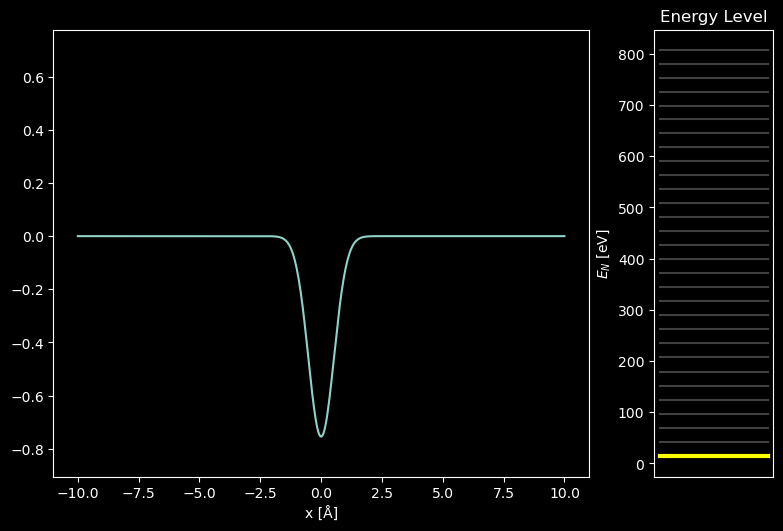

In [8]:
# Harmonic oscillator potential
def harmonic_oscillator(particle):
    k = 100 * eV / Å**2
    return 0.5 * k * particle.x**2

# Define the Hamiltonian
H = Hamiltonian(particles = SingleParticle(), potential = harmonic_oscillator, 
                spatial_ndim = 1, N = 512, extent = 20*Å)

#Diagonalize the Hamiltonian and compute the eigenstates
eigenstates = H.solve(max_states = 30)

# Print out the energies of the eigenstates
print(eigenstates.energies) # the printed energies are expressed in eV

# Visualize the Eigenstates
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)

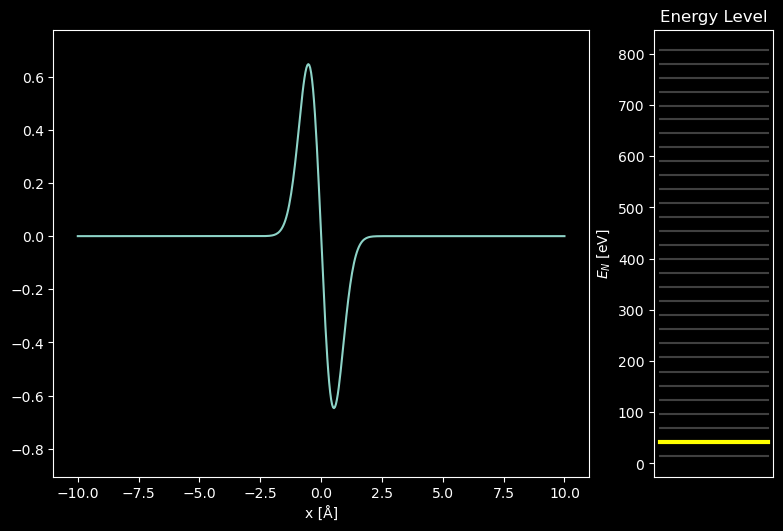

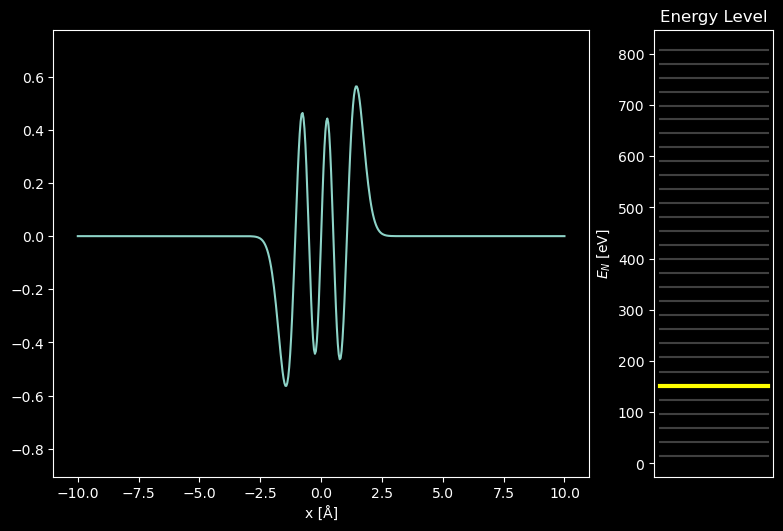

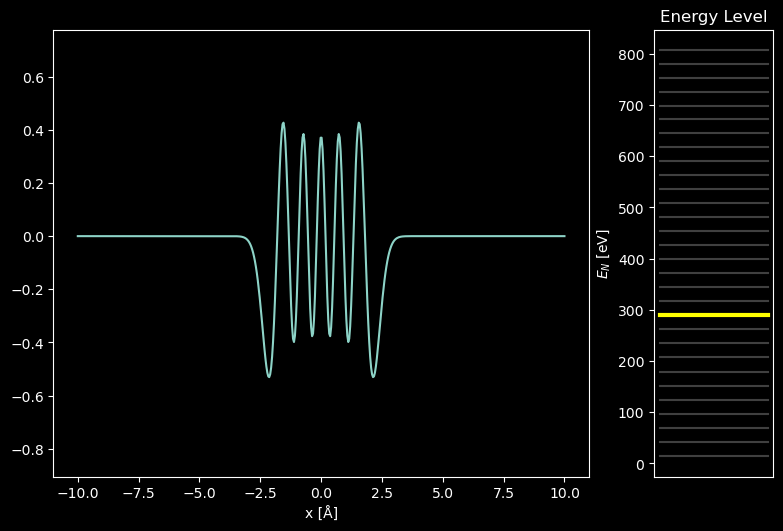

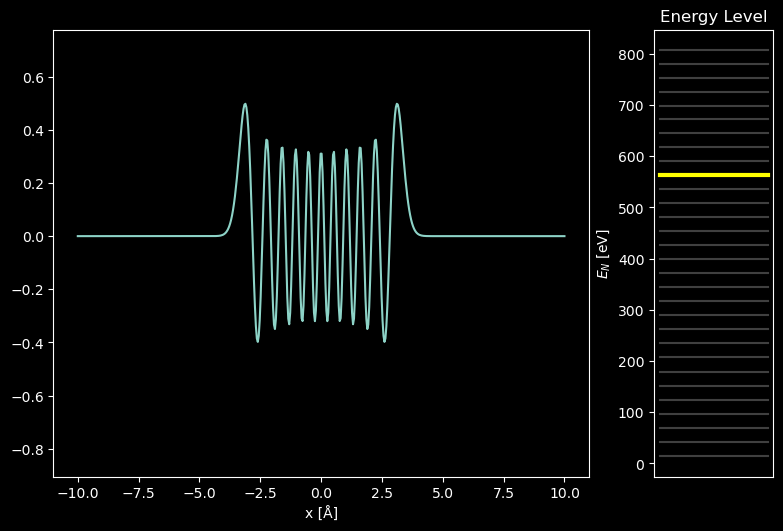

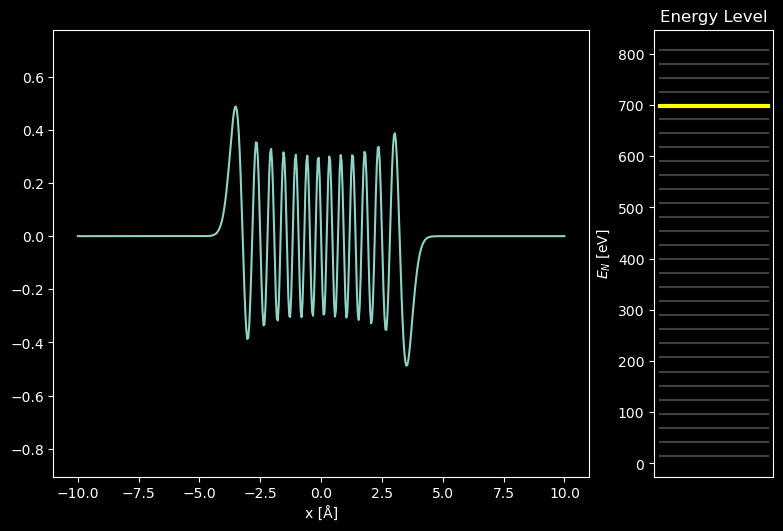

In [9]:
visualization.plot_eigenstate(1)
visualization.plot_eigenstate(5)
visualization.plot_eigenstate(10)
visualization.plot_eigenstate(20)
visualization.plot_eigenstate(25)

<ol start=5>
    <li>What is on the x-axis of your plots?</li>
    <li>Are your plots showing wave functions $\psi(x)$ or probability functions $\psi^*(x) \psi(x)$? How do you know?</li>
</ol>

### New potential: infinite square well

Below I define the infinite square well potential for $L = 8$ Angstroms and plot the two lowest-energy eigenstates (compare to Figure 6.3 in your textbook).

5. The x-axis of my plots are the particle's position. The units are in angstorms.

6. The plots are showing the wave function and not probability functions. I know this because both positive and negative values are displayed on the y-axis. The proability function includes both an absolute value and squares the wave function meaning no negative energy values would appear. In additon, the oscillatory behavior matches the osciallatory behavior of a high-energy eigenfunction meaning just from the wave shape, it is clear the plots are showing wave functions and not probability functions. 

Computing...
Took 0.009137153625488281
[  0.58926935   2.35704264   5.30321556   9.4276143   14.7299955
  21.21004635  28.8673845   37.70155819  47.71204619  58.89825789
  71.2595333   84.79514311  99.50428872 115.3861023  132.43964681
 150.6639161  170.05783494 190.6202591  212.34997539 235.24570176
 259.30608737 284.52971266 310.91508944 338.46066097 367.16480207
 397.0258192  428.04195057 460.21136622 493.53216816 528.00239048]


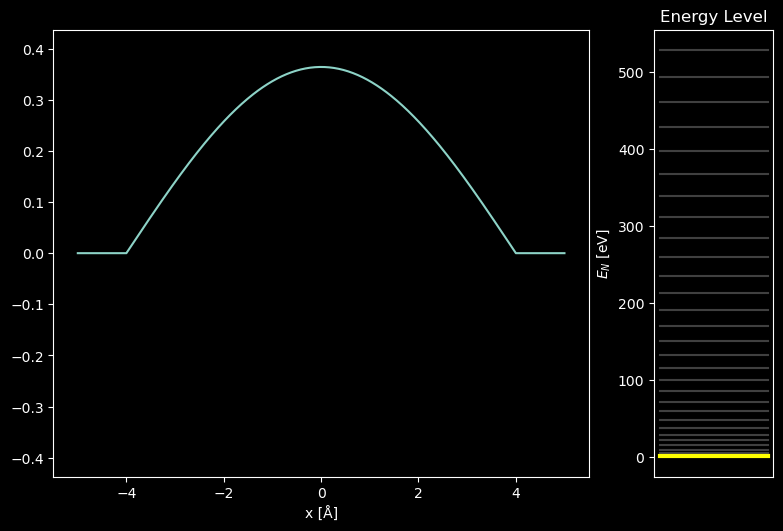

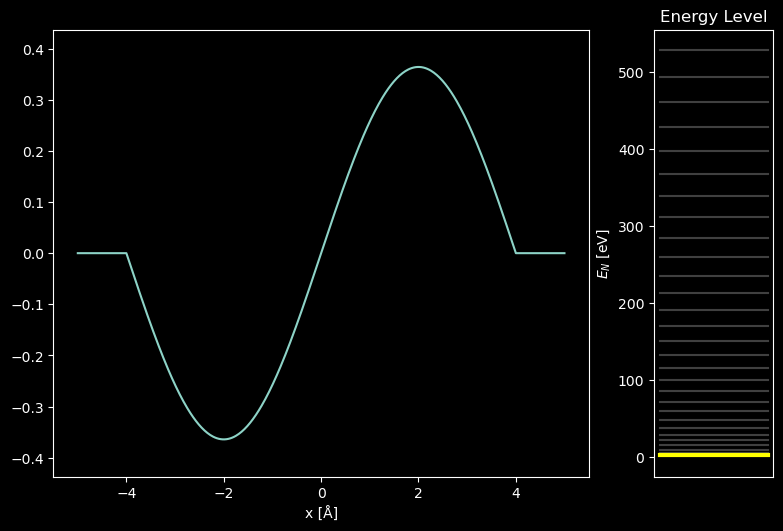

In [10]:
# 8 angstrom-wide infinite square well
def infinite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 4*Å
    potential[out_of_bounds] = np.inf
    return potential

# Define the Hamiltonian of the infinite square well
H_sw = Hamiltonian(particles = SingleParticle(), potential = infinite_square_well, 
                   spatial_ndim = 1, N = 512, extent = 10*Å)

# Diagonalize the Hamiltonian and compute the eigenstates
eigenstates_sw = H_sw.solve(max_states = 30)

print(eigenstates_sw.energies)

# Visualize the infinite square well eigenstates
visualization_sw = init_visualization(eigenstates_sw)
visualization_sw.plot_eigenstate(0)
visualization_sw.plot_eigenstate(1)

<ol start=7>
    <li>Plot any three infinite square well eigenstates of your choice.</li>
    <li>What property do the infinite square well eigenstates have that's different than the SHO eigenstates? (Hint: think about the properties of valid wave functions we discussed in class)</li>
    <li>What is the relationship between the number of extrema (maxima plus minima) in each eigenstate plot and the quantum number of the eigenstate?</li>
</ol>

In [ ]:
visualization_sw.plot_eigenstate(10)
visualization_sw.plot_eigenstate(15)
visualization_sw.plot_eigenstate(25)

8. The infinite square well eigenstates have to be exactly zero at the walls of the well because the potential energy is infinite at those spots whereas the simple harmonic osciallators do not have hard walls. Instead, the wave functions gradually decay to zero as x approaches infinity but not exactly zero at finite boundaries. It is hard to see on the plots, but there is a sharp turn straight to zero for the infinite square well plots whereas there is a more gradual curve to zero for the SHO plots. 

9. The relationship between the quantum number of the eigenstate and the number of extrema is n+1 where n representes the quantum number and n+1 is the number of extrema on the plots. We can see that clearly on both sets of plots where a quantum number of 0 created a parabola and a quantum number of 1 created a cubic shaped graph. 

### Now it's your turn to define a potential

<ol start=10>
    <li>Write a function that defines a <em>finite square-well</em> potential (textbook section 5.4). You can choose the width of the well in Angstroms and the potential at the walls in eV. Calculate the finite square-well Hamiltonian and plot any five eigenstates you choose.</li>
    <li>Based on your plots, do you think a particle can get out of the finite square-well potential no matter its quantum number $n$?</li>
</ol>

Computing...
Took 0.005807161331176758
[ 0.48052454  1.91723598  4.29399663  7.57725906 11.69748429 16.47252425
 20.57574731 21.04087685 21.91723196 23.8237541  24.74428259 27.38680306
 29.23660064 31.22211692 34.4983954  36.81855032 39.68251118 43.41771857
 46.35850973 49.87791219]


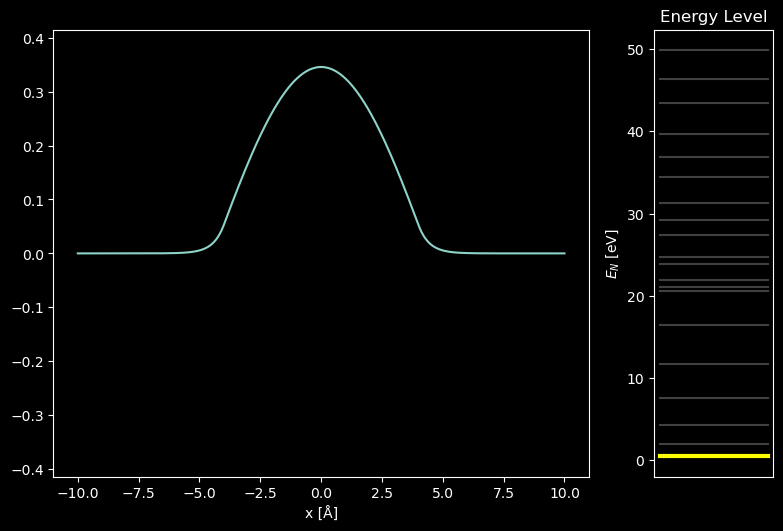

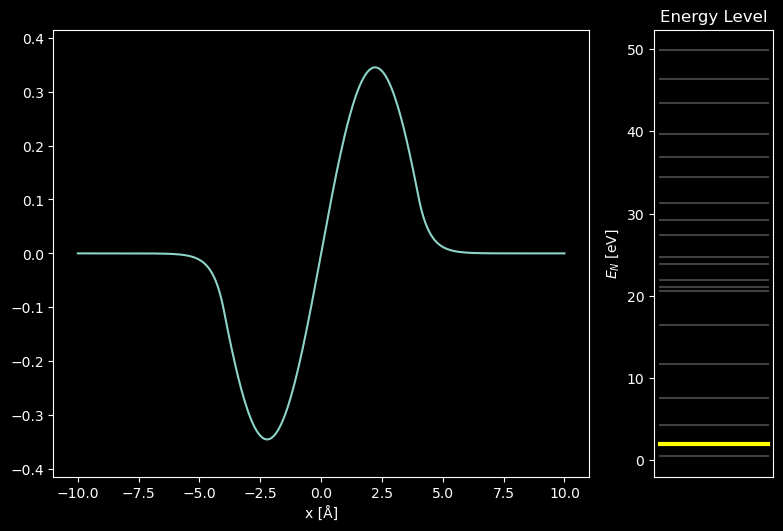

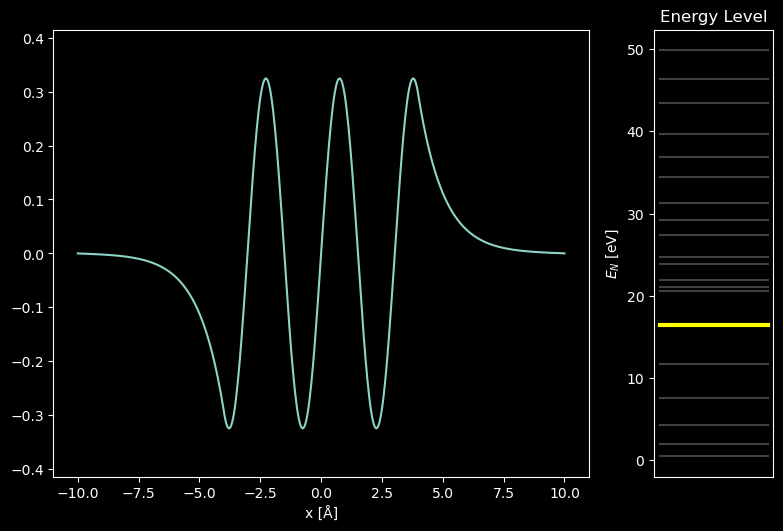

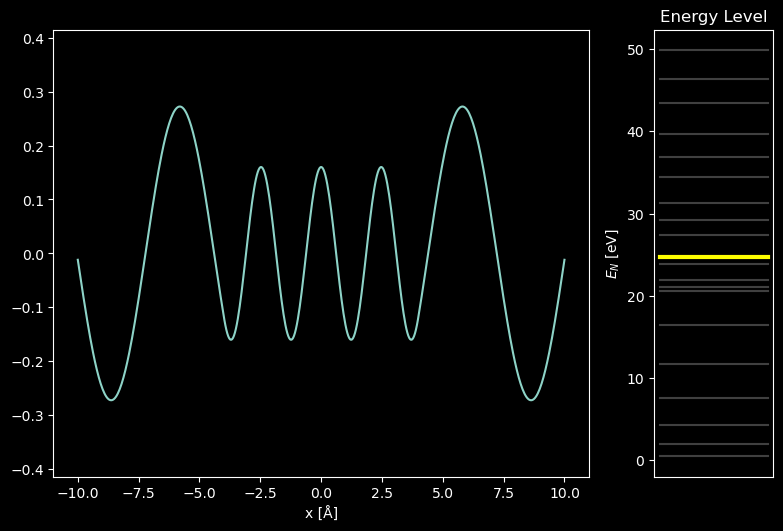

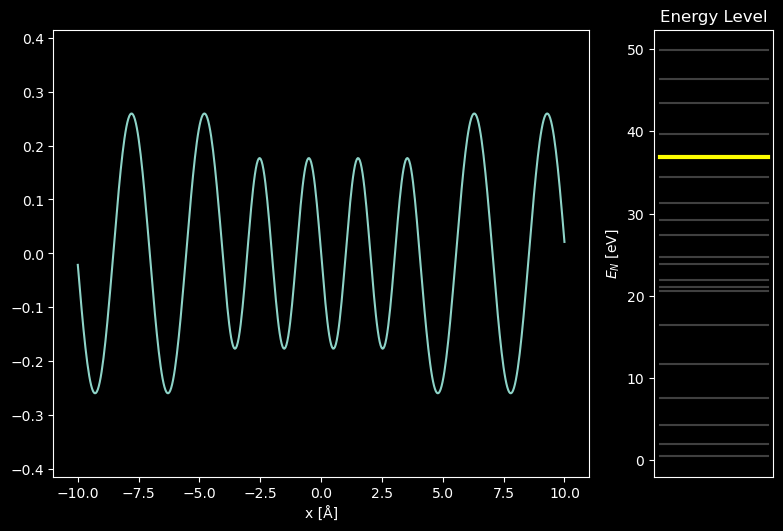

In [6]:
def finite_square_well(particle):
    V0 = 20 * eV
    a = 4 * Å
    x = particle.x
    return np.where(np.abs(x) < a, 0, V0)

H = Hamiltonian(particles = SingleParticle(), potential = finite_square_well, 
                spatial_ndim = 1, N = 512, extent = 20*Å)

eigenstates = H.solve(max_states = 20)

print(eigenstates.energies)

visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)
visualization.plot_eigenstate(1)
visualization.plot_eigenstate(5)
visualization.plot_eigenstate(10)
visualization.plot_eigenstate(15)

11. Based on the plots, I think that a some particles could get out of the finite square-well potential but not if they have a small quantum number n. All that is required is for the energy of the particle to be greater than the wall height. There is a very low possibility of a particle getting out of the potential with a small quantum number because the eigenstates are mostly confined within the walls, but as quantum number n increases, the energy of the eigenstates increase and eventually the energy will exceed the wall hiehgt. This is visible in the plots as only the last two plots have waves that exceed the height of the inner waves. The eigenstates with small quantum numbers have the same height within all waves. 